# Exploratory Data Analysis

## Objective

In this notebook, I'll explore Google Trends data related to domestic violence support resources to identify patterns over time. By analyzing search interest across different topics, I hope to better understand how people seek information online and what insights public search data can provide.

## Research Question 1
Which domestic violence support-related search term had the highest average Google search interest between 2019 and 2025?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# loading the cleaned dataset

trends = pd.read_csv("../data/raw/cleaned/google_trends_cleaned.csv")

trends["date"] = pd.to_datetime(trends["date"])

trends.head()

,date,domestic violence help,abuse hotline,women's shelter,emotional abuse,teen dating violence,isPartial
0,2019-01-01,11,46,95,82,6,False
1,2019-02-01,10,38,79,84,13,False
2,2019-03-01,10,39,82,90,4,False
3,2019-04-01,12,42,81,85,4,False
4,2019-05-01,12,41,83,83,4,False


In [3]:
# calculate the average search interest for each topic

average_interest = trends.drop(columns=["date", "isPartial"]).mean()

average_interest.sort_values(ascending=False)

emotional abuse           80.297619
women's shelter           73.095238
abuse hotline             35.345238
domestic violence help    13.083333
teen dating violence       3.809524
dtype: float64

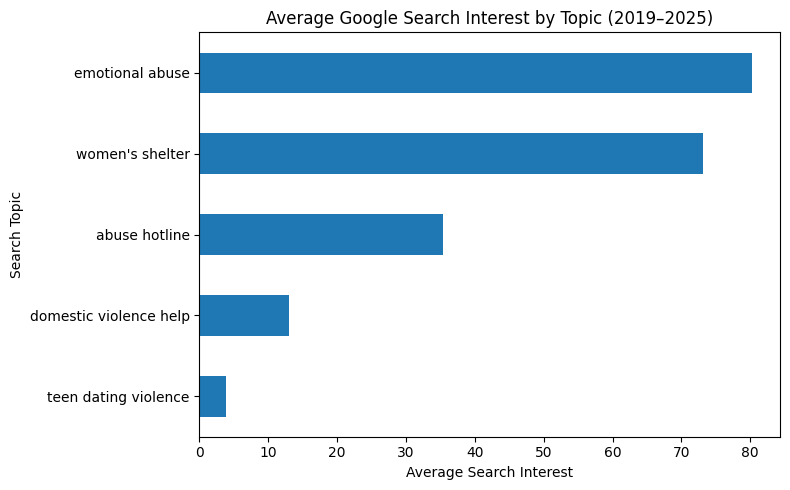

In [4]:
# creating a bar chart based of the average search interest

average_interest.sort_values().plot(kind="barh", figsize=(8, 5))

plt.title("Average Google Search Interest by Topic (2019–2025)")
plt.xlabel("Average Search Interest")
plt.ylabel("Search Topic")

plt.tight_layout()
plt.show()

## Findings

The average search interest shows that **"emotional abuse"** had the highest level of search interest between 2019 and 2025, followed by **"women's shelter."** In comparison, **"domestic violence help"** and **"teen dating violence"** had much lower average search interest.

These results describe how often different topics were searched on Google during the study period. While search interest does not measure the prevalence of domestic violence, it can provide insight into the kinds of information people are looking for online.

## Research Question 2

How did search interest for each domestic violence support-related term change over time between 2019 and 2025?

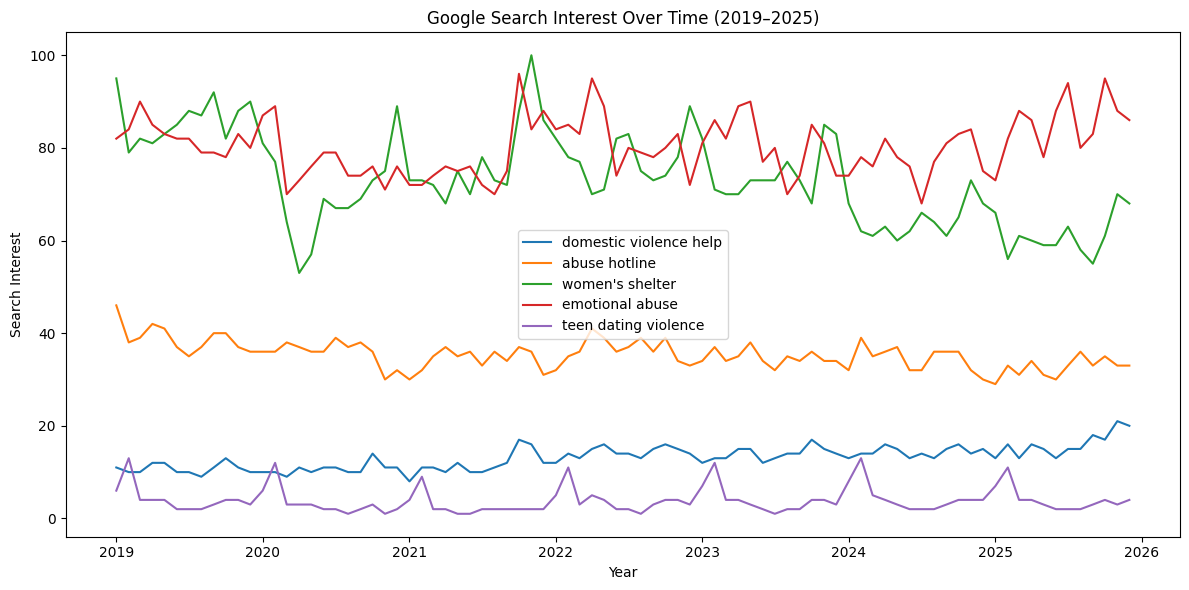

In [5]:
# plotting search interest over time

search_terms = [
    "domestic violence help",
    "abuse hotline",
    "women's shelter",
    "emotional abuse",
    "teen dating violence"
]

plt.figure(figsize=(12, 6))

for term in search_terms:
    plt.plot(trends["date"], trends[term], label=term)

plt.title("Google Search Interest Over Time (2019–2025)")
plt.xlabel("Year")
plt.ylabel("Search Interest")
plt.legend()
plt.tight_layout()

plt.show()

## Findings

Looking at the graph, I noticed that search interest changed over time instead of staying constant. "Emotional abuse" remained one of the most searched terms throughout the study period, while "women's shelter" also stayed relatively high despite some fluctuations.

One trend that stood out to me was that searches for "domestic violence help" gradually increased over time. Although it never became the most searched term, the steady increase could suggest growing awareness or a greater willingness to search for support online.

Overall, the graph shows that different types of support-related searches follow different patterns over time. This makes me interested in exploring whether certain events or awareness campaigns may have influenced these changes.

## Research Question 3

Do domestic violence support-related search terms show recurring seasonal patterns throughout the year?

In [6]:
# extracting the month from each date

trends["month"] = trends["date"].dt.month

trends[["date", "month"]].head()

,date,month
0,2019-01-01,1
1,2019-02-01,2
2,2019-03-01,3
3,2019-04-01,4
4,2019-05-01,5


In [7]:
# calculating the average search interest for each month

monthly_average = trends.groupby("month")[
    [
        "domestic violence help",
        "abuse hotline",
        "women's shelter",
        "emotional abuse",
        "teen dating violence"
    ]
].mean()

monthly_average

,domestic violence help,abuse hotline,women's shelter,emotional abuse,teen dating violence
month,,,,,
1,11.285714,34.142857,78.142857,79.000000,6.142857
2,12.571429,35.714286,70.857143,82.285714,11.571429
3,11.857143,35.428571,69.571429,80.428571,3.571429
4,13.571429,37.428571,66.428571,83.714286,3.714286
5,13.571429,36.714286,68.285714,81.285714,3.000000
6,11.857143,34.428571,71.428571,78.857143,1.857143
7,12.428571,34.428571,74.000000,79.285714,1.857143
8,12.142857,36.571429,71.571429,75.571429,1.714286
9,13.571429,35.857143,70.714286,77.714286,2.571429


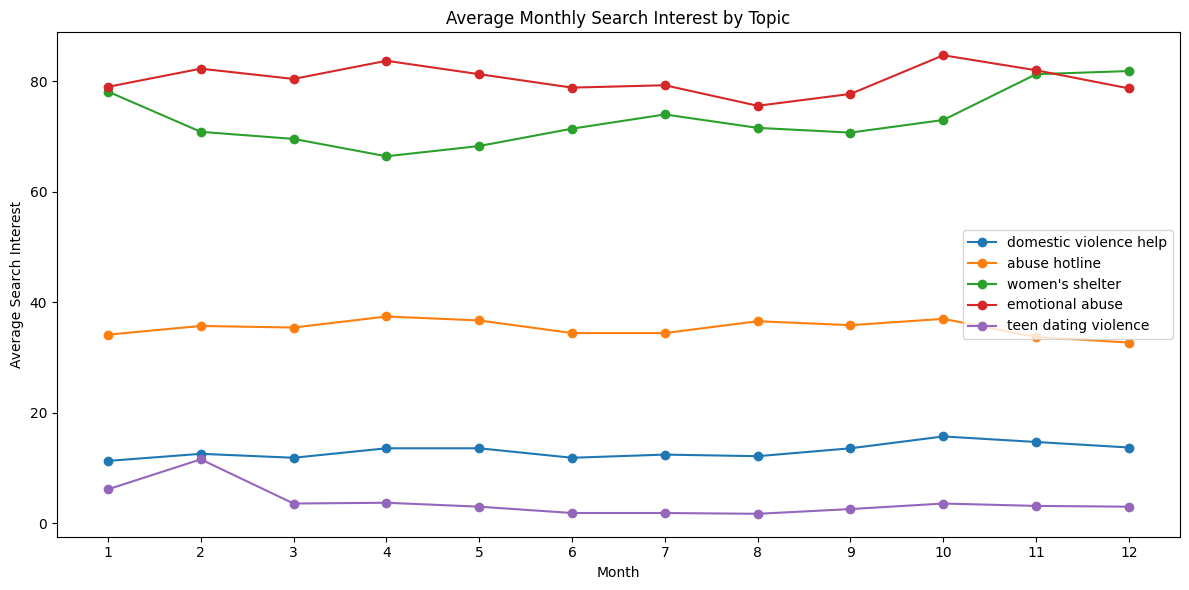

In [8]:
# plotting the average monthly search interest

plt.figure(figsize=(12, 6))

for term in monthly_average.columns:
    plt.plot(monthly_average.index, monthly_average[term], marker="o", label=term)

plt.title("Average Monthly Search Interest by Topic")
plt.xlabel("Month")
plt.ylabel("Average Search Interest")
plt.xticks(range(1, 13))
plt.legend()

plt.tight_layout()
plt.show()

### Findings

Looking at the monthly averages, I don't see any strong seasonal pattern across the different search terms. Most topics stay relatively consistent throughout the year, although there are small increases and decreases in certain months.

For example, searches for "emotional abuse" remain consistently high across nearly every month, while "domestic violence help" stays lower but shows slight increases toward the end of the year. Overall, the differences between months are fairly small compared to the differences between search terms.

Based on this analysis, search interest appears to be more consistent throughout the year than I originally expected. This suggests that people may be looking for information and support year-round rather than only during specific seasons.

## Research Question 4

Are any domestic violence support-related search terms strongly correlated with one another?

In [9]:
# calculating correlations between search terms

correlation = trends[
    [
        "domestic violence help",
        "abuse hotline",
        "women's shelter",
        "emotional abuse",
        "teen dating violence"
    ]
].corr()

correlation

,domestic violence help,abuse hotline,women's shelter,emotional abuse,teen dating violence
domestic violence help,1.000000,-0.142974,-0.279481,0.397140,0.022998
abuse hotline,-0.142974,1.000000,0.263133,0.198172,0.078605
women's shelter,-0.279481,0.263133,1.000000,0.068101,-0.055810
emotional abuse,0.397140,0.198172,0.068101,1.000000,0.214682
teen dating violence,0.022998,0.078605,-0.055810,0.214682,1.000000


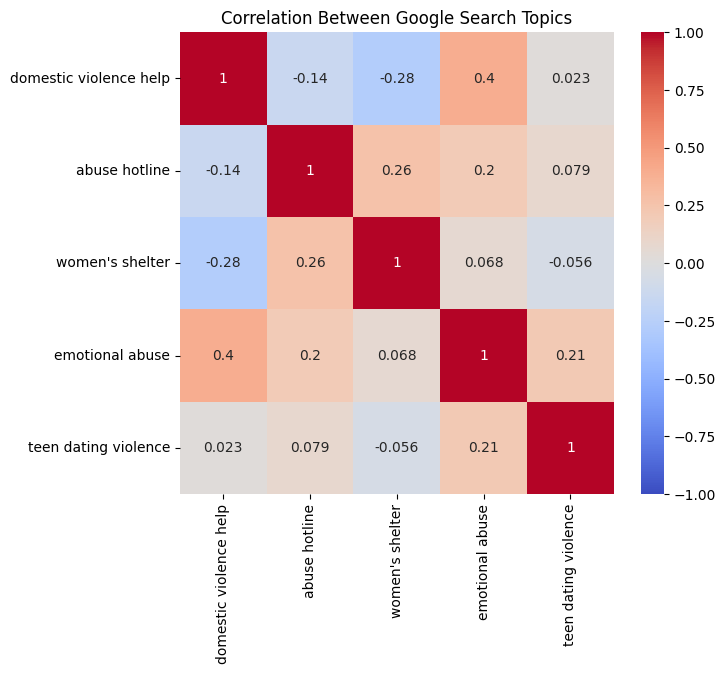

In [10]:
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Google Search Topics")

plt.show()

## Findings

The correlation heatmap shows that most of the search topics have relatively weak relationships with one another. The strongest positive relationship appears between "domestic violence help" and "emotional abuse," suggesting that interest in these topics tends to increase and decrease together over time. Most other relationships are close to zero, indicating that each search topic follows its own pattern rather than moving together consistently.

Overall, this suggests that people search for different types of domestic violence support resources independently depending on their specific needs or circumstances.